In [1]:
import uclchem
from glob import glob
from joblib import Parallel, delayed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [4]:
# set a parameter dictionary for phase 1 collapse model

out_species = ["H2", "C+","CO","CH","CH+","CH2+","CH2","C2H+","C2H2+","C2H3+","C2H2","C4H5"]
param_dict = {
    "endAtFinalDensity": False,  # stop at finalTime
    "freefall": False,  # don't increase density in freefall
    "initialDens": 1e4,  # starting density
    "initialTemp": 100.0,  # temperature of gas
    "finalTime": 1.0e7,  # final time
    "rout": 0.1,  # radius of cloud in pc
    "baseAv": 1.0,  # visual extinction at cloud edge.
    "outputFile": "../examples/test-output/static-full.dat",  # full UCLCHEM output
    "abundSaveFile": "../examples/test-output/startstatic.dat",  # save final abundances to file
}
# Ensure the output directory is present:
if not os.path.exists("../examples/test-output/"):
    os.makedirs("../examples/test-output/")

result = uclchem.model.cloud(param_dict=param_dict, out_species=out_species)
print(result)

[0, 0.49996851430046557, 1.2464910290501138e-08, 0.00017579558193156204, 4.144710627417142e-10, 1.1642273784600051e-15, 6.076604193535823e-15, 1.3964795139299758e-10, 1.9322881217102048e-17, 2.4113164686967578e-15, 4.83986352226703e-14, 7.033931800512068e-11, 1.8837217284806234e-16]


In [5]:
result_df = uclchem.analysis.read_output_file("../examples/test-output/static-full.dat")
result_df.head()

,Time,Density,gasTemp,dustTemp,Av,radfield,zeta,point,H,H+,...,@OCS,@C4N,@SIC3,@SO2,@S2,@HS2,@H2S2,E-,BULK,SURFACE
0,0.000000e+00,10000.0,100.0,100.0,2.9287,1.0,1.0,1,0.5,1.000000e-30,...,1.000000e-30,1.000000e-30,1.000000e-30,1.000000e-30,1.000000e-30,1.000000e-30,1.000000e-30,0.000182,1.000000e-30,1.000000e-30
1,1.000000e-07,10000.0,100.0,100.0,2.9287,1.0,1.0,1,0.5,9.674390e-18,...,1.000000e-30,1.000000e-30,1.000000e-30,1.000000e-30,1.000000e-30,1.000000e-30,1.000000e-30,0.000182,4.012420e-27,1.977870e-16
2,1.000000e-06,10000.0,100.0,100.0,2.9287,1.0,1.0,1,0.5,9.674820e-17,...,1.000000e-30,1.000000e-30,1.000000e-30,1.000000e-30,1.000000e-30,1.000000e-30,1.000000e-30,0.000182,3.754430e-25,1.933850e-15
3,1.000000e-05,10000.0,100.0,100.0,2.9287,1.0,1.0,1,0.5,9.679150e-16,...,1.000000e-30,1.000000e-30,1.000000e-30,1.000000e-30,1.000000e-30,1.000000e-30,1.000000e-30,0.000182,3.745160e-23,1.931680e-14
4,1.000000e-04,10000.0,100.0,100.0,2.9287,1.0,1.0,1,0.5,9.722100e-15,...,1.000000e-30,1.000000e-30,1.000000e-30,1.000000e-30,1.000000e-30,1.000000e-30,1.000000e-30,0.000182,3.744310e-21,1.931460e-13


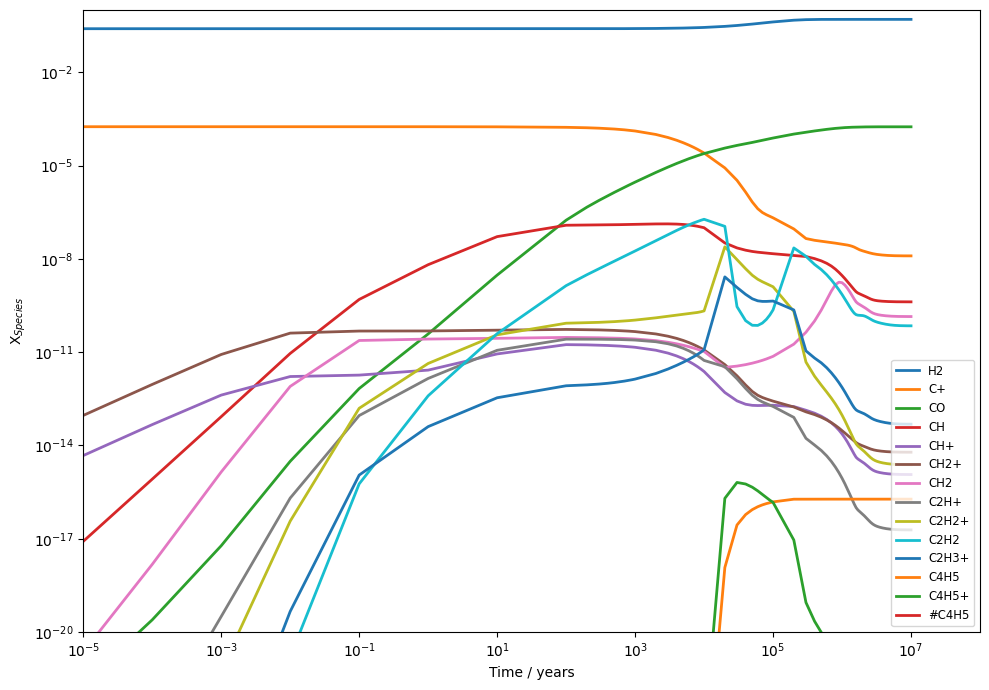

In [ ]:
species = ["H2", "C+","CO","CH","CH+","CH2+","CH2","C2H+","C2H2+","C2H2","C2H3+","C4H5","C4H5+"]
fig, ax = uclchem.analysis.create_abundance_plot(result_df, species, figsize=(10, 7))
ax = ax.set(xscale="log", ylim=(1e-20, 1), xlim=(1e-5, 1e8))